In [1]:
from pathlib import Path
import json
import time
import random
import inspect

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

current_directory = Path.cwd().resolve()
if (current_directory / 'FINAL').is_dir():
    project_folder = current_directory / 'FINAL'
elif current_directory.name == 'FINAL':
    project_folder = current_directory
elif current_directory.parent.name == 'FINAL':
    project_folder = current_directory.parent
else:
    project_folder = current_directory

dataset_candidates = [
    project_folder / 'GNO evolution' / 'process_data_evolution' / 'particle_evolution_dataset.npz',
]
dataset_path = next((candidate for candidate in dataset_candidates if candidate.exists()), dataset_candidates[0])
training_results_folder = project_folder / 'model_pt' / 'train_model_evolution'
results_folder = training_results_folder / 'test_plots'
results_folder.mkdir(parents=True, exist_ok=True)
checkpoint_path = training_results_folder / 'best_task1_v3_model.pt'
history_path = training_results_folder / 'history.json'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Project folder          :', project_folder)
print('Dataset path            :', dataset_path)
print('Checkpoint path         :', checkpoint_path)
print('Analysis results folder :', results_folder)
print('Device                  :', device)
if device.type == 'cuda':
    print('GPU                     :', torch.cuda.get_device_name(0))

if not dataset_path.exists():
    raise FileNotFoundError('Missing particle_evolution_dataset.npz. Run FINAL/processdata_states.py with TASK1_TARGET_MODE="delta" or "both" first.')
if not checkpoint_path.exists():
    raise FileNotFoundError('Missing best_task1_v3_model.pt. Run FINAL/GNO_model_evolution.ipynb training first.')


Project folder          : /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/FINAL
Dataset path            : /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/FINAL/GNO evolution/process_data_evolution/particle_evolution_dataset.npz
Checkpoint path         : /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/FINAL/model_pt/train_model_evolution/best_task1_v3_model.pt
Analysis results folder : /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/FINAL/model_pt/train_model_evolution/test_plots
Device                  : cuda
GPU                     : NVIDIA GeForce RTX 5070 Ti


In [3]:
# Load checkpoint first, because its feature list defines the exact input channels used by the saved model.
# This is important when the model notebook changes input-channel toggles after an older checkpoint was trained.
try:
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location=device)

checkpoint_feature_names = [str(name) for name in checkpoint.get('feature_names', [])]
checkpoint_target_names = [str(name) for name in checkpoint.get('target_names', [])]
model_config = dict(checkpoint.get('model_config', {}))
settings = dict(checkpoint.get('settings', {}))
loss_name = str(checkpoint.get('loss_name', 'unknown'))

if len(checkpoint_feature_names) == 0:
    raise RuntimeError('Checkpoint does not contain feature_names. Cannot safely reconstruct model inputs.')
if len(checkpoint_target_names) == 0:
    raise RuntimeError('Checkpoint does not contain target_names. Cannot safely reconstruct targets.')

print('Checkpoint best epoch     :', checkpoint.get('best_epoch', 'unknown'))
print('Checkpoint best metric    :', checkpoint.get('best_checkpoint_metric', 'unknown'))
print('Checkpoint loss           :', loss_name)
print('Checkpoint model config   :', model_config)
print('Checkpoint input features :', checkpoint_feature_names)
print('Checkpoint targets        :', checkpoint_target_names)

# Load optional training history saved by the model notebook. Older runs may not have this file.
if history_path.exists():
    history = json.loads(history_path.read_text())
    print('Loaded training history rows:', len(history))
else:
    history = []
    print('[info] No history.json found. Learning-curve plots will be skipped, but checkpoint evaluation still works.')



Checkpoint best epoch     : 52
Checkpoint best metric    : 0.062479128246195614
Checkpoint loss           : smooth_l1
Checkpoint model config   : {'hidden_size': 128, 'graph_layers': 3, 'neighbor_radius': 0.12, 'dropout': 0.06}
Checkpoint input features : ['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma', 'geom_dist', 'geom_nx', 'geom_ny', 'geom_nz', 'angle_of_attack', 'phase']
Checkpoint targets        : ['dx', 'dy', 'dz', 'dGamma_x', 'dGamma_y', 'dGamma_z', 'dsigma']
Loaded training history rows: 60


In [4]:
# Load dataset arrays and slice them to the checkpoint feature/target order.
# Evolution preprocessing is pair-based: one item is x_t -> delta_state.
dataset_file = np.load(dataset_path, allow_pickle=True)
raw_feature_names_from_file = [str(name) for name in dataset_file['feature_names'].tolist()]
target_names_from_file = [str(name) for name in dataset_file['target_names'].tolist()]

if target_names_from_file[:3] != ['dx', 'dy', 'dz']:
    raise RuntimeError(f'This analysis notebook expects delta targets starting with dx,dy,dz; got {target_names_from_file}')

# Pair metadata is the evolution equivalent of frame metadata used by the u/gradU notebook.
if 'pair_contexts' in dataset_file.files and 'pair_ranges' in dataset_file.files:
    frame_contexts = list(dataset_file['pair_contexts'])
    frame_ranges = list(dataset_file['pair_ranges'])
    split_id_keys = {
        'train': 'train_pair_ids',
        'val': 'val_pair_ids',
        'test': 'test_pair_ids',
    }
else:
    # Backward compatibility if someone regenerates a frame-wise alias file later.
    frame_contexts = list(dataset_file['frame_contexts'])
    frame_ranges = list(dataset_file['frame_ranges'])
    split_id_keys = {
        'train': 'train_frame_ids',
        'val': 'val_frame_ids',
        'test': 'test_frame_ids',
    }

missing_features = [name for name in checkpoint_feature_names if name not in raw_feature_names_from_file]
if missing_features:
    raise RuntimeError(f'Checkpoint expects features missing from dataset: {missing_features}')
missing_targets = [name for name in checkpoint_target_names if name not in target_names_from_file]
if missing_targets:
    raise RuntimeError(f'Checkpoint expects targets missing from dataset: {missing_targets}')

active_input_feature_indices = [raw_feature_names_from_file.index(name) for name in checkpoint_feature_names]
target_indices = [target_names_from_file.index(name) for name in checkpoint_target_names]
feature_names = list(checkpoint_feature_names)
target_names = list(checkpoint_target_names)

if target_names[:3] != ['dx', 'dy', 'dz']:
    raise RuntimeError(f'Checkpoint target_names do not look like delta evolution targets: {target_names}')

if 'inputs_by_frame_norm' in dataset_file.files and 'targets_by_frame_norm' in dataset_file.files:
    inputs_by_frame_normalized = [
        np.asarray(x, dtype=np.float32)[:, active_input_feature_indices]
        for x in dataset_file['inputs_by_frame_norm'].tolist()
    ]
    targets_by_frame_normalized = [
        np.asarray(y, dtype=np.float32)[:, target_indices]
        for y in dataset_file['targets_by_frame_norm'].tolist()
    ]
    inputs_by_frame_raw = [
        np.asarray(x, dtype=np.float32)[:, active_input_feature_indices]
        for x in dataset_file['inputs_by_frame'].tolist()
    ]
    targets_by_frame_raw = [
        np.asarray(y, dtype=np.float32)[:, target_indices]
        for y in dataset_file['targets_by_frame'].tolist()
    ]
else:
    required_pair_keys = ['inputs_t', 'targets_delta', 'inputs_t_norm', 'targets_delta_norm', 'pair_ranges']
    missing_pair_keys = [key for key in required_pair_keys if key not in dataset_file.files]
    if missing_pair_keys:
        raise RuntimeError(f'This notebook expects particle_evolution_dataset.npz keys; missing {missing_pair_keys}')

    inputs_t = np.asarray(dataset_file['inputs_t'], dtype=np.float32)
    targets_delta = np.asarray(dataset_file['targets_delta'], dtype=np.float32)
    inputs_t_norm = np.asarray(dataset_file['inputs_t_norm'], dtype=np.float32)
    targets_delta_norm = np.asarray(dataset_file['targets_delta_norm'], dtype=np.float32)

    inputs_by_frame_raw = []
    targets_by_frame_raw = []
    inputs_by_frame_normalized = []
    targets_by_frame_normalized = []
    for pair_range in frame_ranges:
        start = int(pair_range[3])
        end = int(pair_range[4])
        inputs_by_frame_raw.append(inputs_t[start:end, :][:, active_input_feature_indices])
        targets_by_frame_raw.append(targets_delta[start:end, :][:, target_indices])
        inputs_by_frame_normalized.append(inputs_t_norm[start:end, :][:, active_input_feature_indices])
        targets_by_frame_normalized.append(targets_delta_norm[start:end, :][:, target_indices])

input_mean = dataset_file['in_mean'].astype(np.float32).reshape(-1)[active_input_feature_indices]
input_standard_deviation = dataset_file['in_std'].astype(np.float32).reshape(-1)[active_input_feature_indices]
target_mean_np = dataset_file['out_mean'].astype(np.float32).reshape(-1)[target_indices]
target_standard_deviation_np = dataset_file['out_std'].astype(np.float32).reshape(-1)[target_indices]
output_mean = torch.tensor(target_mean_np, dtype=torch.float32, device=device)
output_standard_deviation = torch.tensor(target_standard_deviation_np, dtype=torch.float32, device=device)


def frame_context_as_dict(frame_id):
    context = frame_contexts[int(frame_id)]
    if isinstance(context, dict):
        return context
    if hasattr(context, 'item'):
        maybe_dict = context.item()
        if isinstance(maybe_dict, dict):
            return maybe_dict
    return dict(context)


def pair_time_sort_value(frame_id):
    context = frame_context_as_dict(int(frame_id))
    value = context.get('frame_t', context.get('frame', context.get('fr', frame_ranges[int(frame_id)][1])))
    try:
        return int(float(value))
    except Exception:
        digits = ''.join(ch for ch in str(value) if ch.isdigit())
        return int(digits) if digits else int(frame_id)


def split_ids(primary_key, fallback_key=None):
    if primary_key in dataset_file.files:
        return dataset_file[primary_key].astype(np.int64)
    if fallback_key and fallback_key in dataset_file.files:
        return dataset_file[fallback_key].astype(np.int64)
    return np.array([], dtype=np.int64)

training_frame_ids = split_ids(split_id_keys['train'], 'train_frame_ids')
validation_frame_ids = split_ids('val_id_frame_ids')
validation_angle_frame_ids = split_ids('validation_angle_frame_ids', split_id_keys['val'])
testing_frame_ids = split_ids(split_id_keys['test'], 'test_frame_ids')


def make_same_distribution_validation_split(train_ids, stride=5, offset=2, min_per_case=8):
    by_case = {}
    for frame_id in np.asarray(train_ids, dtype=np.int64):
        case = str(frame_context_as_dict(int(frame_id)).get('case', frame_ranges[int(frame_id)][0]))
        by_case.setdefault(case, []).append(int(frame_id))

    train_out = []
    validation_out = []
    for case, ids in sorted(by_case.items()):
        ids_sorted = sorted(ids, key=pair_time_sort_value)
        if len(ids_sorted) <= 1:
            train_out.extend(ids_sorted)
            continue
        stride_value = max(int(stride), 2)
        offset_value = min(max(int(offset), 0), stride_value - 1)
        validation_ids = ids_sorted[offset_value::stride_value]
        minimum_validation = min(max(int(min_per_case), 1), max(len(ids_sorted) - 1, 1))
        if len(validation_ids) < minimum_validation:
            existing = set(validation_ids)
            validation_ids.extend([j for j in ids_sorted if j not in existing][:minimum_validation - len(validation_ids)])
        validation_set = set(validation_ids)
        train_out.extend([j for j in ids_sorted if j not in validation_set])
        validation_out.extend(validation_ids)
    return np.asarray(sorted(train_out), dtype=np.int64), np.asarray(sorted(validation_out), dtype=np.int64)

if len(validation_frame_ids) == 0:
    print('[warn] same-distribution validation ids missing/empty; rebuilding split in memory from training pairs.')
    training_frame_ids, validation_frame_ids = make_same_distribution_validation_split(training_frame_ids)


def sample_frame_ids(frame_ids, maximum_frames=None, seed_offset=0, sort_after_sampling=False):
    frame_ids = np.asarray(frame_ids, dtype=np.int64)
    if maximum_frames is None or len(frame_ids) <= int(maximum_frames):
        chosen = frame_ids.copy()
    else:
        rng = np.random.default_rng(SEED + int(seed_offset))
        chosen = rng.choice(frame_ids, size=int(maximum_frames), replace=False)
    if sort_after_sampling:
        chosen = np.asarray(sorted(chosen, key=pair_time_sort_value), dtype=np.int64)
    return chosen


def sample_dataset_indices(dataset, maximum_items=None, seed_offset=0):
    indices = np.arange(len(dataset), dtype=np.int64)
    if maximum_items is None or len(indices) <= int(maximum_items):
        return indices
    rng = np.random.default_rng(SEED + int(seed_offset))
    return rng.choice(indices, size=int(maximum_items), replace=False)


def test_frame_ids_for_role(role_name, saved_key, aoa_fallback=None):
    if saved_key in dataset_file.files:
        return dataset_file[saved_key].astype(np.int64)
    selected = []
    for frame_id in testing_frame_ids:
        context = frame_context_as_dict(int(frame_id))
        if str(context.get('test_role', '')) == role_name:
            selected.append(int(frame_id))
            continue
        if aoa_fallback is not None and int(round(float(context.get('aoa_deg', -999)))) == int(aoa_fallback):
            selected.append(int(frame_id))
    return np.asarray(selected, dtype=np.int64)


def target_norm_for_frame(frame_id):
    target = targets_by_frame_raw[int(frame_id)]
    return float(np.linalg.norm(target.reshape(-1)))


def filter_zero_target_frames(frame_ids, split_name, minimum_norm=1.0e-12):
    kept = []
    removed = []
    for frame_id in np.asarray(frame_ids, dtype=np.int64):
        norm_value = target_norm_for_frame(int(frame_id))
        if norm_value > minimum_norm:
            kept.append(int(frame_id))
        else:
            context = frame_context_as_dict(int(frame_id))
            removed.append((int(frame_id), context.get('case', 'unknown'), context.get('frame_t', context.get('frame', 'unknown'))))
    if removed:
        print(f'[filter] {split_name}: removed {len(removed)} zero-delta pairs; examples={removed[:3]}')
    return np.asarray(kept, dtype=np.int64)


testing_normal_frame_ids = test_frame_ids_for_role('testing_normal', 'test_normal_frame_ids', aoa_fallback=27)
testing_super_resolution_frame_ids = test_frame_ids_for_role('testing_super_resolution', 'test_super_resolution_frame_ids', aoa_fallback=19)
testing_unseen_angle_frame_ids = test_frame_ids_for_role('testing_unseen_angle', 'test_unseen_angle_frame_ids', aoa_fallback=32)

training_frame_ids = filter_zero_target_frames(training_frame_ids, 'training')
validation_frame_ids = filter_zero_target_frames(validation_frame_ids, 'validation')
validation_angle_frame_ids = filter_zero_target_frames(validation_angle_frame_ids, 'validation_angle')
testing_frame_ids = filter_zero_target_frames(testing_frame_ids, 'testing_all')
testing_normal_frame_ids = filter_zero_target_frames(testing_normal_frame_ids, 'testing_normal')
testing_super_resolution_frame_ids = filter_zero_target_frames(testing_super_resolution_frame_ids, 'testing_super_resolution')
testing_unseen_angle_frame_ids = filter_zero_target_frames(testing_unseen_angle_frame_ids, 'testing_unseen_angle')

input_dimension = int(inputs_by_frame_normalized[0].shape[1])
output_dimension = int(targets_by_frame_normalized[0].shape[1])
print('Input features used by checkpoint:', feature_names)
print('Target names:', target_names)
print('Pairs: train/val/test =', len(training_frame_ids), len(validation_frame_ids), len(testing_frame_ids))


[warn] same-distribution validation ids missing/empty; rebuilding split in memory from training pairs.
Input features used by checkpoint: ['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma', 'geom_dist', 'geom_nx', 'geom_ny', 'geom_nz', 'angle_of_attack', 'phase']
Target names: ['dx', 'dy', 'dz', 'dGamma_x', 'dGamma_y', 'dGamma_z', 'dsigma']
Pairs: train/val/test = 1760 440 400


In [5]:
# Dataset wrappers and helper functions used by analysis/evaluation.

class ParticleFrameDataset(Dataset):
    def __init__(self, frame_ids):
        self.frame_ids = [int(frame_id) for frame_id in frame_ids]

    def __len__(self):
        return len(self.frame_ids)

    def __getitem__(self, index):
        frame_id = self.frame_ids[index]
        input_normalized = torch.from_numpy(inputs_by_frame_normalized[frame_id])
        target_normalized = torch.from_numpy(targets_by_frame_normalized[frame_id])
        input_raw = torch.from_numpy(inputs_by_frame_raw[frame_id])
        context = frame_context_as_dict(frame_id)
        metadata = {
            'frame_id': frame_id,
            'pair_id': frame_id,
            'case': str(context.get('case', 'unknown')),
            'frame_t': str(context.get('frame_t', context.get('frame', context.get('fr', 'unknown')))),
            'frame_tp1': str(context.get('frame_tp1', 'unknown')),
            'particle_count': int(context.get('n_particles', input_normalized.shape[0])),
        }
        return input_normalized, target_normalized, input_raw, metadata


def collate_one_frame(batch):
    inputs, targets, raw_inputs, metadata = zip(*batch)
    return list(inputs), list(targets), list(raw_inputs), list(metadata)

training_dataset = ParticleFrameDataset(training_frame_ids)
validation_dataset = ParticleFrameDataset(validation_frame_ids)
testing_dataset = ParticleFrameDataset(testing_frame_ids)
testing_normal_dataset = ParticleFrameDataset(testing_normal_frame_ids)
testing_super_resolution_dataset = ParticleFrameDataset(testing_super_resolution_frame_ids)
testing_unseen_angle_dataset = ParticleFrameDataset(testing_unseen_angle_frame_ids)

training_loader = DataLoader(training_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
validation_loader = DataLoader(validation_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_loader = DataLoader(testing_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_normal_loader = DataLoader(testing_normal_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_super_resolution_loader = DataLoader(testing_super_resolution_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_unseen_angle_loader = DataLoader(testing_unseen_angle_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)

# Use checkpoint settings if present; otherwise safe analysis defaults.
settings.setdefault('particles_per_frame_final', 2048)
settings.setdefault('maximum_particles_before_gpu', 6000)
settings.setdefault('validation_frames_per_check', 20)


def denormalize_target(target_normalized):
    return target_normalized * output_standard_deviation + output_mean


# def subsample_before_gpu(input_tensor, target_tensor, raw_input_tensor, maximum_particles):
#     particle_count = input_tensor.shape[0]
#     if particle_count <= maximum_particles:
#         return input_tensor, target_tensor, raw_input_tensor
#     picked = torch.randperm(particle_count)[:maximum_particles]
#     return input_tensor[picked], target_tensor[picked], raw_input_tensor[picked]

def subsample_particles(input_tensor, target_tensor, raw_input_tensor, max_particles):
    """Deterministic or random subsampling to a cap."""
    n = input_tensor.shape[0]
    if n <= max_particles:
        return input_tensor, target_tensor, raw_input_tensor
    # Use fixed random seed for reproducibility
    rng = torch.Generator(device=input_tensor.device).manual_seed(42)
    idx = torch.randperm(n, generator=rng, device=input_tensor.device)[:max_particles]
    return input_tensor[idx], target_tensor[idx], raw_input_tensor[idx]


# def subsample_for_training(input_tensor, target_tensor, raw_input_tensor, particle_cap):
#     particle_count = input_tensor.shape[0]
#     if particle_count <= particle_cap:
#         return input_tensor, target_tensor, raw_input_tensor
#     picked = torch.randperm(particle_count, device=input_tensor.device)[:particle_cap]
#     return input_tensor[picked], target_tensor[picked], raw_input_tensor[picked]


def finite_mean(values):
    finite = [float(v) for v in values if np.isfinite(v)]
    return float(np.mean(finite)) if finite else np.nan

minimum_target_norm_for_relative_error = 1e-6


def component_metrics(prediction, target):
    difference = prediction - target
    target_norm = torch.linalg.norm(target.reshape(-1))
    difference_norm = torch.linalg.norm(difference.reshape(-1))
    relative_error = np.nan if target_norm.item() <= minimum_target_norm_for_relative_error else (difference_norm / target_norm).item()
    rmse = torch.sqrt(torch.mean(difference ** 2)).item()
    mae = torch.mean(torch.abs(difference)).item()
    target_rms = torch.sqrt(torch.mean(target ** 2)).item()
    return relative_error, rmse, mae, target_norm.item(), target_rms


def physical_metrics(prediction_normalized, target_normalized):
    prediction = denormalize_target(prediction_normalized)
    target = denormalize_target(target_normalized)
    full_rel, full_rmse, full_mae, _, _ = component_metrics(prediction, target)

    # Position (dx,dy,dz)
    pos_rel, pos_rmse, pos_mae, _, _ = component_metrics(prediction[:, :3], target[:, :3])
    
    # Gamma vector (dGamma_x, dGamma_y, dGamma_z) – assuming next three are Gamma
    gamma_rel, gamma_rmse, gamma_mae, _, _ = component_metrics(prediction[:, 3:6], target[:, 3:6])
    
    # Sigma (dsigma) – if present, else handle gracefully
    if prediction.shape[1] >= 7:
        sigma_rel, sigma_rmse, sigma_mae, _, _ = component_metrics(prediction[:, 6:7], target[:, 6:7])
    else:
        sigma_rel = sigma_rmse = sigma_mae = np.nan

    return {
        'relative_error': full_rel,
        'rmse': full_rmse,
        'mae': full_mae,
        'delta_position_relative_error': pos_rel,
        'delta_position_rmse': pos_rmse,
        'delta_position_mae': pos_mae,
        'delta_gamma_relative_error': gamma_rel,
        'delta_gamma_rmse': gamma_rmse,
        'delta_gamma_mae': gamma_mae,
        'delta_sigma_relative_error': sigma_rel,
        'delta_sigma_rmse': sigma_rmse,
        'delta_sigma_mae': sigma_mae,
    }

@torch.no_grad()
def evaluate_model(data_loader, maximum_frames, particle_cap):
    if len(data_loader.dataset) == 0:
        return {'relative_error': np.nan, 'rmse': np.nan, 'mae': np.nan, 'delta_position_relative_error': np.nan, 'delta_position_rmse': np.nan, 'delta_strength_relative_error': np.nan, 'delta_strength_rmse': np.nan, 'frames_evaluated': 0, 'frames_skipped_for_relative_error': 0}
    model.eval()
    collected = []
    skipped_for_relative = 0
    sampled_indices = sample_dataset_indices(data_loader.dataset, maximum_frames, seed_offset=67)
    for dataset_index in sampled_indices:
        input_tensor, target_tensor, raw_input_tensor, metadata = data_loader.dataset[int(dataset_index)]
        # input_tensor, target_tensor, raw_input_tensor = subsample_before_gpu(input_tensor, target_tensor, raw_input_tensor, settings['maximum_particles_before_gpu'])
        # input_tensor, target_tensor, raw_input_tensor = subsample_for_training(input_tensor.to(device), target_tensor.to(device), raw_input_tensor.to(device), particle_cap)
        input_tensor, target_tensor, raw_input_tensor = subsample_particles(input_tensor.to(device), target_tensor.to(device), raw_input_tensor.to(device), particle_cap)
        prediction = model(input_tensor).float()
        metrics = physical_metrics(prediction, target_tensor.float())
        if not np.isfinite(metrics['relative_error']):
            skipped_for_relative += 1
        collected.append(metrics)
    return {
        'relative_error': finite_mean([m['relative_error'] for m in collected]),
        'rmse': finite_mean([m['rmse'] for m in collected]),
        'mae': finite_mean([m['mae'] for m in collected]),
        'delta_position_relative_error': finite_mean([m['delta_position_relative_error'] for m in collected]),
        'delta_position_rmse': finite_mean([m['delta_position_rmse'] for m in collected]),
        'delta_strength_relative_error': finite_mean([m['delta_strength_relative_error'] for m in collected]),
        'delta_strength_rmse': finite_mean([m['delta_strength_rmse'] for m in collected]),
        'frames_evaluated': int(len(collected)),
        'frames_skipped_for_relative_error': int(skipped_for_relative),
    }


In [6]:
# Reconstruct the model architecture from checkpoint state-dict keys, then load saved weights.
# This supports both older GNOBlock checkpoints and newer edge-feature-message checkpoints.

state_dict = checkpoint['model_state_dict']
state_keys = list(state_dict.keys())
uses_legacy_gnoblock = any('.integral_transform.' in key for key in state_keys)
uses_edge_feature_block = any('.message_network.' in key for key in state_keys)


def relative_l2_error(prediction, target, small_number=1e-12):
    difference = (prediction - target).reshape(prediction.shape[0], -1)
    reference = target.reshape(target.shape[0], -1)
    return (torch.linalg.norm(difference, dim=1) / torch.linalg.norm(reference, dim=1).clamp_min(small_number)).mean()


if uses_legacy_gnoblock:
    from neuralop.layers.gno_block import GNOBlock

    class LegacyParticleVelocityGradientModel(nn.Module):
        def __init__(self, input_size, output_size, hidden_size=96, graph_layers=2, neighbor_radius=0.12, dropout=0.04):
            super().__init__()
            self.neighbor_radius = float(neighbor_radius)
            self.input_network = nn.Sequential(
                nn.Linear(input_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Linear(hidden_size, hidden_size),
            )

            block_arguments = {}
            signature = inspect.signature(GNOBlock.__init__)
            if 'use_torch_scatter_reduce' in signature.parameters:
                try:
                    import torch_scatter  # noqa: F401
                    block_arguments['use_torch_scatter_reduce'] = True
                except Exception:
                    block_arguments['use_torch_scatter_reduce'] = False
            if 'use_open3d_neighbor_search' in signature.parameters:
                try:
                    import open3d  # noqa: F401
                    block_arguments['use_open3d_neighbor_search'] = True
                except Exception:
                    block_arguments['use_open3d_neighbor_search'] = False

            self.graph_blocks = nn.ModuleList([
                GNOBlock(
                    in_channels=hidden_size,
                    out_channels=hidden_size,
                    coord_dim=3,
                    radius=self.neighbor_radius,
                    transform_type='linear',
                    reduction='mean',
                    pos_embedding_type='transformer',
                    pos_embedding_channels=16,
                    channel_mlp_layers=[hidden_size, hidden_size, hidden_size],
                    **block_arguments,
                )
                for _ in range(graph_layers)
            ])
            self.normalization_layers = nn.ModuleList([nn.LayerNorm(hidden_size) for _ in range(graph_layers)])
            self.output_network = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, output_size),
            )
            self.backend_information = {'checkpoint_architecture': 'legacy_gnoblock', **block_arguments}

        def forward(self, particle_features):
            particle_positions = particle_features[:, :3]
            hidden = self.input_network(particle_features)
            neighbor_cache = None
            for graph_block, normalization_layer in zip(self.graph_blocks, self.normalization_layers):
                if neighbor_cache is None:
                    neighbor_cache = graph_block.neighbor_search(
                        data=particle_positions,
                        queries=particle_positions,
                        radius=self.neighbor_radius,
                    )
                embedded_positions = graph_block.pos_embedding(particle_positions) if graph_block.pos_embedding is not None else particle_positions
                update = graph_block.integral_transform(
                    y=embedded_positions,
                    x=embedded_positions,
                    neighbors=neighbor_cache,
                    f_y=hidden,
                )
                if update.ndim == 3 and update.shape[0] == 1:
                    update = update.squeeze(0)
                hidden = normalization_layer(hidden + update)
            return self.output_network(hidden)

    model = LegacyParticleVelocityGradientModel(
        input_size=input_dimension,
        output_size=output_dimension,
        **model_config,
    ).to(device)

else:
    from neuralop.layers.neighbor_search import NeighborSearch

    class EdgeFeatureMessageBlock(nn.Module):
        def __init__(self, hidden_size, neighbor_radius, use_open3d_neighbor_search=True, dropout=0.04):
            super().__init__()
            self.neighbor_radius = float(neighbor_radius)
            self.neighbor_search = NeighborSearch(use_open3d=use_open3d_neighbor_search, return_norm=False)
            edge_feature_size = 2 * hidden_size + 14
            self.message_network = nn.Sequential(
                nn.Linear(edge_feature_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Linear(hidden_size, hidden_size),
            )
            self.normalization = nn.LayerNorm(hidden_size)

        def forward(self, hidden, search_positions, physical_positions, gamma_values, sigma_values):
            neighbors = self.neighbor_search(data=search_positions, queries=search_positions, radius=self.neighbor_radius)
            source_index = neighbors['neighbors_index'].long()
            row_splits = neighbors['neighbors_row_splits'].long()
            neighbor_counts = row_splits[1:] - row_splits[:-1]
            if source_index.numel() == 0:
                return hidden
            target_index = torch.repeat_interleave(torch.arange(search_positions.shape[0], device=search_positions.device), neighbor_counts)
            relative_position = physical_positions[source_index] - physical_positions[target_index]
            distance = torch.linalg.norm(relative_position, dim=-1, keepdim=True)
            sigma_source = sigma_values[source_index].abs().clamp_min(1.0e-8)
            sigma_target = sigma_values[target_index].abs().clamp_min(1.0e-8)
            edge_features = torch.cat([
                hidden[source_index],
                hidden[target_index],
                relative_position,
                distance,
                distance / sigma_source,
                distance / sigma_target,
                gamma_values[source_index],
                gamma_values[target_index],
                sigma_source,
                sigma_target,
            ], dim=-1)
            messages = self.message_network(edge_features)
            aggregated = torch.zeros_like(hidden)
            aggregated.index_add_(0, target_index, messages)
            aggregated = aggregated / neighbor_counts.to(hidden.dtype).clamp_min(1.0).unsqueeze(-1)
            return self.normalization(hidden + aggregated)

    class ParticleVelocityGradientModel(nn.Module):
        def __init__(self, input_size, output_size, feature_names, input_mean, input_standard_deviation, hidden_size=96, graph_layers=2, neighbor_radius=0.12, dropout=0.04, use_physical_edge_features=True):
            super().__init__()
            self.neighbor_radius = float(neighbor_radius)
            self.feature_names = list(feature_names)
            self.use_physical_edge_features = bool(use_physical_edge_features)
            self.register_buffer('input_mean', torch.as_tensor(input_mean, dtype=torch.float32).reshape(1, -1))
            self.register_buffer('input_standard_deviation', torch.as_tensor(input_standard_deviation, dtype=torch.float32).reshape(1, -1))
            self.sigma_index = self.feature_names.index('sigma') if 'sigma' in self.feature_names else -1
            self.gamma_indices = [self.feature_names.index(name) for name in ['Gamma_x', 'Gamma_y', 'Gamma_z'] if name in self.feature_names]
            if len(self.gamma_indices) != 3:
                self.gamma_indices = []
            self.input_network = nn.Sequential(
                nn.Linear(input_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Linear(hidden_size, hidden_size),
            )
            try:
                import open3d  # noqa: F401
                use_open3d = True
            except Exception:
                use_open3d = False
            self.graph_blocks = nn.ModuleList([
                EdgeFeatureMessageBlock(hidden_size, self.neighbor_radius, use_open3d_neighbor_search=use_open3d, dropout=dropout)
                for _ in range(graph_layers)
            ])
            self.output_network = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, output_size),
            )
            self.backend_information = {'checkpoint_architecture': 'edge_feature_message', 'neighbor_search': 'open3d' if use_open3d else 'native_torch'}

        def physical_feature_values(self, particle_features):
            if not self.use_physical_edge_features:
                return particle_features
            return particle_features * self.input_standard_deviation.to(particle_features.dtype) + self.input_mean.to(particle_features.dtype)

        def forward(self, particle_features):
            search_positions = particle_features[:, :3]
            physical_features = self.physical_feature_values(particle_features)
            physical_positions = physical_features[:, :3]
            sigma_values = physical_features[:, self.sigma_index:self.sigma_index + 1] if self.sigma_index >= 0 else torch.ones((particle_features.shape[0], 1), device=particle_features.device, dtype=particle_features.dtype)
            gamma_values = physical_features[:, self.gamma_indices] if self.gamma_indices else torch.zeros((particle_features.shape[0], 3), device=particle_features.device, dtype=particle_features.dtype)
            hidden = self.input_network(particle_features)
            for graph_block in self.graph_blocks:
                hidden = graph_block(hidden, search_positions, physical_positions, gamma_values, sigma_values)
            return self.output_network(hidden)

    model = ParticleVelocityGradientModel(
        input_size=input_dimension,
        output_size=output_dimension,
        feature_names=feature_names,
        input_mean=input_mean,
        input_standard_deviation=input_standard_deviation,
        **model_config,
    ).to(device)

try:
    model.load_state_dict(state_dict, strict=True)
except RuntimeError as error:
    raise RuntimeError(
        'Checkpoint does not match the reconstructed model. Make sure task1_v3_analysis.ipynb '
        'is using the same checkpoint produced by FINAL/GNO_model_evolution.ipynb.'
    ) from error

model.eval()
trainable_parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print('Loaded checkpoint:', checkpoint_path)
print('Architecture      :', model.backend_information)
print('Trainable params  :', f'{trainable_parameter_count:,}')


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded checkpoint: /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/FINAL/model_pt/train_model_evolution/best_task1_v3_model.pt
Architecture      : {'checkpoint_architecture': 'edge_feature_message', 'neighbor_search': 'open3d'}
Trainable params  : 256,135


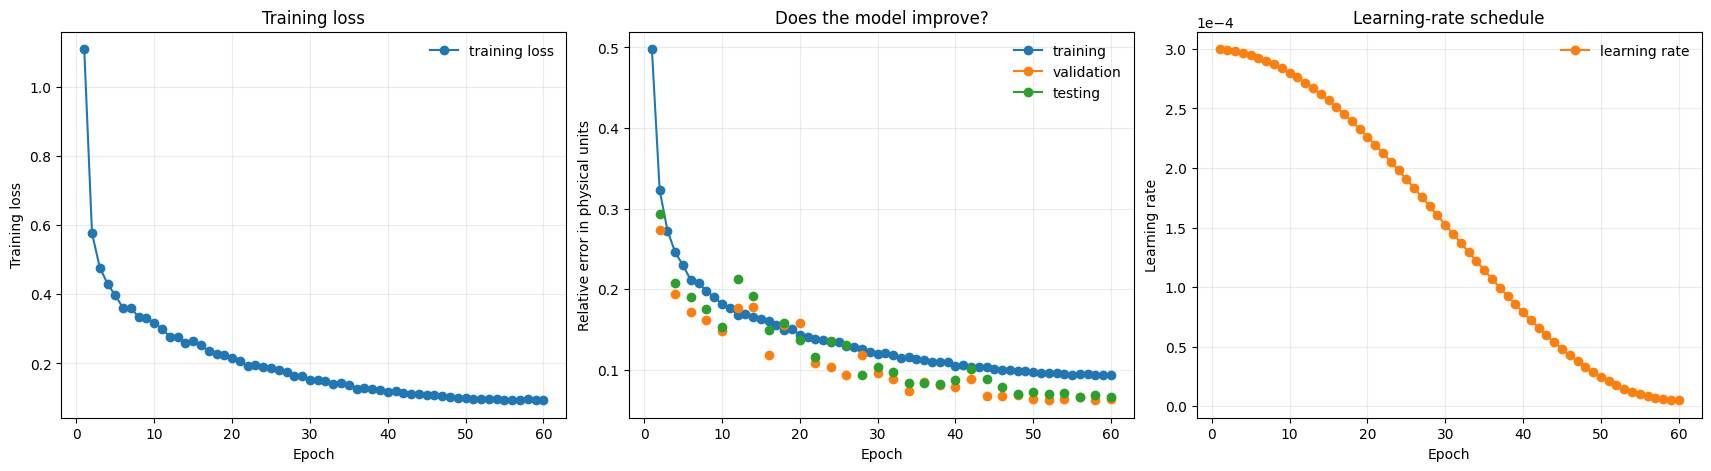

Saved: /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/FINAL/model_pt/train_model_evolution/test_plots/basic_learning_curves.png


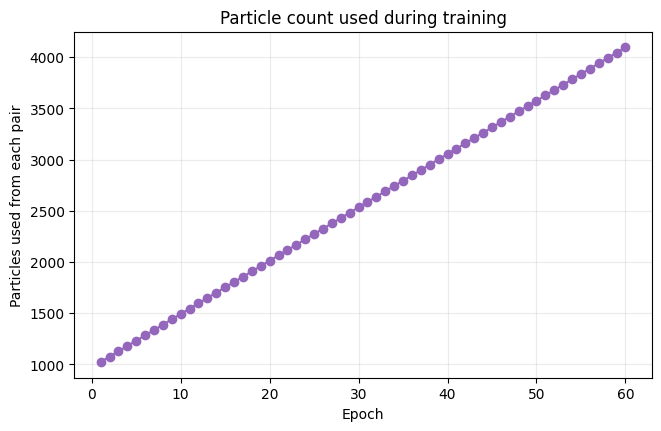

Saved: /hpc/home/neerajc/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/FINAL/model_pt/train_model_evolution/test_plots/particles_used_per_epoch.png


In [7]:
# Learning curves from saved training history.
# If the model was trained before history.json was added, this section is skipped.

if len(history) == 0:
    print('[skip] No saved training history found. Re-run FINAL/GNO_model_evolution.ipynb once to create history.json.')
else:
    epochs = [row['epoch'] for row in history]
    training_loss = [row['training_loss'] for row in history]
    training_relative_error = [row['training_relative_error'] for row in history]
    validation_relative_error = [row.get('validation_relative_error', np.nan) for row in history]
    testing_relative_error = [row.get('testing_relative_error', np.nan) for row in history]
    learning_rates = [row['learning_rate'] for row in history]
    particle_caps = [row['particle_cap'] for row in history]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)

    axes[0].plot(epochs, training_loss, marker='o', label='training loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Training loss')
    axes[0].set_title('Training loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].plot(epochs, training_relative_error, marker='o', label='training')
    axes[1].plot(epochs, validation_relative_error, marker='o', label='validation')
    axes[1].plot(epochs, testing_relative_error, marker='o', label='testing')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Relative error in physical units')
    axes[1].set_title('Does the model improve?')
    axes[1].grid(alpha=0.25)
    axes[1].legend(frameon=False)

    axes[2].plot(epochs, learning_rates, marker='o', color='tab:orange', label='learning rate')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning rate')
    axes[2].set_title('Learning-rate schedule')
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[2].grid(alpha=0.25)
    axes[2].legend(frameon=False)

    plot_path = results_folder / 'basic_learning_curves.png'
    fig.savefig(plot_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', plot_path)

    fig, axis = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
    axis.plot(epochs, particle_caps, marker='o', color='tab:purple')
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Particles used from each pair')
    axis.set_title('Particle count used during training')
    axis.grid(alpha=0.25)
    plot_path = results_folder / 'particles_used_per_epoch.png'
    fig.savefig(plot_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', plot_path)


In [8]:
# Learning-curve plotting is handled in the previous cell.


In [ ]:
# Final metrics using the best checkpoint loaded at the end of training.
# Empty validation/testing splits are skipped while those cases are still being generated.

final_particle_cap = settings['particles_per_frame_final']
final_metrics = {}
final_metrics['training'] = evaluate_model(training_loader, maximum_frames=12, particle_cap=final_particle_cap)
if len(validation_dataset) > 0:
    final_metrics['validation'] = evaluate_model(validation_loader, maximum_frames=20, particle_cap=final_particle_cap)
if len(testing_dataset) > 0:
    final_metrics['testing_all'] = evaluate_model(testing_loader, maximum_frames=20, particle_cap=final_particle_cap)
if len(testing_normal_dataset) > 0:
    final_metrics['testing_normal'] = evaluate_model(testing_normal_loader, maximum_frames=20, particle_cap=final_particle_cap)
if len(testing_super_resolution_dataset) > 0:
    final_metrics['testing_super_resolution'] = evaluate_model(testing_super_resolution_loader, maximum_frames=20, particle_cap=final_particle_cap)
if len(testing_unseen_angle_dataset) > 0:
    final_metrics['testing_unseen_angle'] = evaluate_model(testing_unseen_angle_loader, maximum_frames=20, particle_cap=final_particle_cap)

print(json.dumps(final_metrics, indent=2))

figure, axis = plt.subplots(figsize=(7.2, 4.5), constrained_layout=True)
split_names = list(final_metrics.keys())
values = [final_metrics[name]['relative_error'] for name in split_names]
metric_colors = ['#4c78a8', '#59a14f', '#e15759', '#b07aa1', '#f28e2b', '#9c755f']
bars = axis.bar(split_names, values, color=metric_colors[:len(split_names)])
axis.tick_params(axis='x', rotation=20)
axis.set_ylabel('Relative error in physical units')
axis.set_title('Final error by split')
axis.grid(axis='y', alpha=0.25)
for bar, value in zip(bars, values):
    axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.3f}', ha='center', va='bottom')
plot_path = results_folder / 'final_relative_error_by_split.png'
figure.savefig(plot_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)


KeyError: 'delta_strength_relative_error'

In [ ]:
# Prediction-versus-true scatter plots.
# Diagonal alignment means good delta-magnitude prediction.

@torch.no_grad()
def collect_prediction_samples(dataset, maximum_frames=6, maximum_particles_per_frame=5000):
    if len(dataset) == 0:
        return None, None
    true_chunks = []
    predicted_chunks = []

    for dataset_index in sample_dataset_indices(dataset, maximum_frames, seed_offset=79):
        input_tensor, target_tensor, raw_input_tensor, metadata = dataset[int(dataset_index)]
        # input_tensor, target_tensor, raw_input_tensor = subsample_before_gpu(
        #     input_tensor, target_tensor, raw_input_tensor, maximum_particles_per_frame
        # )
        input_tensor, target_tensor, raw_input_tensor = subsample_particles(
            input_tensor, target_tensor, raw_input_tensor, maximum_particles_per_frame
        )
        prediction_normalized = model(input_tensor.to(device)).float()
        true_physical = denormalize_target(target_tensor.to(device)).cpu().numpy()
        predicted_physical = denormalize_target(prediction_normalized).cpu().numpy()
        true_chunks.append(true_physical)
        predicted_chunks.append(predicted_physical)

    return np.concatenate(true_chunks, axis=0), np.concatenate(predicted_chunks, axis=0)


def plot_scatter_for_split(split_name, dataset):
    true_values, predicted_values = collect_prediction_samples(dataset)
    if true_values is None:
        print(f'[{split_name}] no data available; skipping scatter plot.')
        return

    # Position magnitude
    true_delta_position = np.linalg.norm(true_values[:, :3], axis=1)
    predicted_delta_position = np.linalg.norm(predicted_values[:, :3], axis=1)
    
    # Gamma vector magnitude (components 3,4,5)
    true_delta_gamma = np.linalg.norm(true_values[:, 3:6], axis=1)
    predicted_delta_gamma = np.linalg.norm(predicted_values[:, 3:6], axis=1)
    
    # Sigma (if present)
    has_sigma = true_values.shape[1] >= 7
    if has_sigma:
        true_delta_sigma = np.abs(true_values[:, 6])
        predicted_delta_sigma = np.abs(predicted_values[:, 6])

    # Determine number of subplots
    n_plots = 2 if not has_sigma else 3
    fig, axes = plt.subplots(1, n_plots, figsize=(5.5*n_plots, 4.8), constrained_layout=True)
    if n_plots == 1:
        axes = [axes]
    
    plot_data = [
        (axes[0], true_delta_position, predicted_delta_position, '|δ position|'),
        (axes[1], true_delta_gamma, predicted_delta_gamma, '|δ Γ|')
    ]
    if has_sigma:
        plot_data.append((axes[2], true_delta_sigma, predicted_delta_sigma, '|δ σ|'))

    for ax, true_arr, pred_arr, title in plot_data:
        if true_arr.shape[0] > 30000:
            rng = np.random.default_rng(SEED)
            idx = rng.choice(true_arr.shape[0], size=30000, replace=False)
            true_arr = true_arr[idx]
            pred_arr = pred_arr[idx]
        low = float(np.quantile(np.concatenate([true_arr, pred_arr]), 0.01))
        high = float(np.quantile(np.concatenate([true_arr, pred_arr]), 0.99))
        ax.scatter(true_arr, pred_arr, s=3, alpha=0.25)
        ax.plot([low, high], [low, high], color='black', linewidth=1.2, linestyle='--')
        ax.set_xlabel(f'true {title}')
        ax.set_ylabel(f'predicted {title}')
        ax.set_title(f'{split_name}: {title}')
        ax.grid(alpha=0.25)

    plot_path = results_folder / f'{split_name.lower()}_prediction_scatter.png'
    fig.savefig(plot_path, dpi=220, bbox_inches='tight')
    plt.close(fig)
    print('Saved:', plot_path)

plot_scatter_for_split('training', training_dataset)
plot_scatter_for_split('validation', validation_dataset)
plot_scatter_for_split('testing_all', testing_dataset)
plot_scatter_for_split('testing_normal', testing_normal_dataset)
plot_scatter_for_split('testing_super_resolution', testing_super_resolution_dataset)
plot_scatter_for_split('testing_unseen_angle', testing_unseen_angle_dataset)


In [ ]:
# Prediction plots for training, validation, and testing.
# Coordinates are input particle locations. The model predicts next-step state increments on those particles.

@torch.no_grad()
def predict_one_frame(dataset, dataset_index=0, maximum_particles_for_plot=12000):
    model.eval()
    if len(dataset) == 0:
        raise RuntimeError('Cannot plot an empty dataset split.')
    dataset_index = min(int(dataset_index), len(dataset) - 1)
    input_tensor, target_tensor, raw_input_tensor, metadata = dataset[dataset_index]
    # input_tensor, target_tensor, raw_input_tensor = subsample_before_gpu(
        # input_tensor, target_tensor, raw_input_tensor, maximum_particles_for_plot
    # )

    input_tensor, target_tensor, raw_input_tensor = subsample_particles(
        input_tensor, target_tensor, raw_input_tensor, maximum_particles_for_plot
    )
    prediction_normalized = model(input_tensor.to(device)).float()
    target_physical = denormalize_target(target_tensor.to(device)).cpu().numpy()
    prediction_physical = denormalize_target(prediction_normalized).cpu().numpy()
    raw_input = raw_input_tensor.numpy()
    return raw_input[:, :3], target_physical, prediction_physical, metadata


def robust_color_limits(values, lower=0.02, upper=0.98):
    finite_values = np.asarray(values)[np.isfinite(values)]
    if finite_values.size == 0:
        return 0.0, 1.0
    low = float(np.quantile(finite_values, lower))
    high = float(np.quantile(finite_values, upper))
    if low >= high:
        high = low + 1e-6
    return low, high


def plot_prediction_example(split_name, dataset, dataset_index=0):
    coordinates, true_values, predicted_values, metadata = predict_one_frame(dataset, dataset_index=dataset_index)

    # Position
    true_pos = np.linalg.norm(true_values[:, :3], axis=1)
    pred_pos = np.linalg.norm(predicted_values[:, :3], axis=1)
    pos_error = pred_pos - true_pos

    # Gamma
    true_gam = np.linalg.norm(true_values[:, 3:6], axis=1)
    pred_gam = np.linalg.norm(predicted_values[:, 3:6], axis=1)
    gam_error = pred_gam - true_gam

    # Sigma (if present)
    has_sigma = true_values.shape[1] >= 7
    if has_sigma:
        true_sig = np.abs(true_values[:, 6])
        pred_sig = np.abs(predicted_values[:, 6])
        sig_error = pred_sig - true_sig

    # Determine grid: 2 rows if no sigma, else 3 rows
    n_rows = 2 if not has_sigma else 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4.5*n_rows), constrained_layout=True)
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    # Color limits
    pos_low, pos_high = robust_color_limits(np.concatenate([true_pos, pred_pos]))
    gam_low, gam_high = robust_color_limits(np.concatenate([true_gam, pred_gam]))
    pos_err_lim = max(abs(robust_color_limits(pos_error)[0]), abs(robust_color_limits(pos_error)[1]), 1e-12)
    gam_err_lim = max(abs(robust_color_limits(gam_error)[0]), abs(robust_color_limits(gam_error)[1]), 1e-12)

    # Row 0: position
    plot_items = [
        (0, 0, true_pos, '|δ position| true', 'viridis', pos_low, pos_high),
        (0, 1, pred_pos, '|δ position| pred', 'viridis', pos_low, pos_high),
        (0, 2, pos_error, '|δ position| error', 'RdBu_r', -pos_err_lim, pos_err_lim),
        (1, 0, true_gam, '|δ Γ| true', 'magma', gam_low, gam_high),
        (1, 1, pred_gam, '|δ Γ| pred', 'magma', gam_low, gam_high),
        (1, 2, gam_error, '|δ Γ| error', 'RdBu_r', -gam_err_lim, gam_err_lim),
    ]
    if has_sigma:
        sig_low, sig_high = robust_color_limits(np.concatenate([true_sig, pred_sig]))
        sig_err_lim = max(abs(robust_color_limits(sig_error)[0]), abs(robust_color_limits(sig_error)[1]), 1e-12)
        plot_items += [
            (2, 0, true_sig, '|δ σ| true', 'plasma', sig_low, sig_high),
            (2, 1, pred_sig, '|δ σ| pred', 'plasma', sig_low, sig_high),
            (2, 2, sig_error, '|δ σ| error', 'RdBu_r', -sig_err_lim, sig_err_lim),
        ]

    for row, col, values, title, cmap, vmin, vmax in plot_items:
        sc = axes[row, col].scatter(
            coordinates[:, 0], coordinates[:, 2],
            c=values, s=3, cmap=cmap, vmin=vmin, vmax=vmax
        )
        axes[row, col].set_title(title)
        axes[row, col].set_xlabel('x')
        axes[row, col].set_ylabel('z')
        axes[row, col].grid(alpha=0.18)
        plt.colorbar(sc, ax=axes[row, col], fraction=0.046, pad=0.02)

    fig.suptitle(
        f"{split_name}: case {metadata['case']}, pair {metadata['frame_t']} -> {metadata['frame_tp1']}, particles shown {coordinates.shape[0]}",
        fontsize=13,
    )
    plot_path = results_folder / f'{split_name.lower()}_prediction_example.png'
    fig.savefig(plot_path, dpi=240, bbox_inches='tight')
    plt.close(fig)
    print('Saved:', plot_path)


plot_prediction_example('training', training_dataset, dataset_index=180)
if len(validation_dataset) > 0:
    plot_prediction_example('validation', validation_dataset, dataset_index=180)
else:
    print('[validation] no data available; skipping prediction image.')
for split_name, split_dataset in [
    ('testing_all', testing_dataset),
    ('testing_normal', testing_normal_dataset),
    ('testing_super_resolution', testing_super_resolution_dataset),
    ('testing_unseen_angle', testing_unseen_angle_dataset),
]:
    if len(split_dataset) > 0:
        plot_prediction_example(split_name, split_dataset, dataset_index=180)
    else:
        print(f'[{split_name}] no data available; skipping prediction image.')


# Temporal target trace for one particle

This cell picks one training case and one testing case, then tracks the same particle index through pair time. It plots normalized target magnitudes for `delta xyz` and `delta Gamma/sigma`.


In [ ]:
# Temporal variation of normalized delta targets for one fixed particle index.
# Choose one train case automatically. You can replace this string manually if needed.
available_training_cases = sorted({frame_context_as_dict(int(frame_id)).get('case', 'unknown') for frame_id in training_frame_ids})
if len(available_training_cases) == 0:
    raise RuntimeError('No training cases available for temporal plotting.')
train_case_name = available_training_cases[0]

def available_cases(frame_ids):
    return sorted({str(frame_context_as_dict(int(frame_id)).get('case', 'unknown')) for frame_id in np.asarray(frame_ids, dtype=np.int64)})

available_testing_cases = available_cases(testing_frame_ids)
test_case_name = available_testing_cases[0] if available_testing_cases else None

particle_index = 0

print('Available training cases:', available_training_cases[:10], '...' if len(available_training_cases) > 10 else '')
print('Chosen training case   :', train_case_name)
print('Available testing cases:', available_testing_cases[:10], '...' if len(available_testing_cases) > 10 else '')
print('Chosen testing case    :', test_case_name)


def frame_time_value(frame_id):
    context = frame_context_as_dict(int(frame_id))
    frame_number = float(context.get('frame_t', context.get('frame', frame_ranges[int(frame_id)][1])))
    dt = float(context.get('dt', 1.0))
    return frame_number * dt


def frames_for_case(frame_ids, case_name):
    selected = [
        int(frame_id)
        for frame_id in np.asarray(frame_ids, dtype=np.int64)
        if str(frame_context_as_dict(int(frame_id)).get('case', 'unknown')) == str(case_name)
    ]
    return sorted(selected, key=pair_time_sort_value)

train_case_frame_ids = frames_for_case(training_frame_ids, train_case_name)
test_case_frame_ids = frames_for_case(testing_frame_ids, test_case_name) if test_case_name is not None else []

print('Training pairs in chosen case:', len(train_case_frame_ids))
print('Testing pairs in chosen case :', len(test_case_frame_ids))


def extract_temporal_target_series(frame_ids, arrays_by_frame, particle_index=0):
    time_values = []
    delta_position_magnitudes = []
    delta_strength_magnitudes = []
    pair_labels = []

    for frame_id in frame_ids:
        target_frame = arrays_by_frame[int(frame_id)]
        if particle_index >= target_frame.shape[0]:
            continue

        particle_target = target_frame[particle_index]
        delta_position_magnitudes.append(np.linalg.norm(particle_target[:3]))
        delta_strength_magnitudes.append(np.linalg.norm(particle_target[3:]))
        time_values.append(frame_time_value(frame_id))
        context = frame_context_as_dict(int(frame_id))
        pair_labels.append(f"{context.get('frame_t', '?')}->{context.get('frame_tp1', '?')}")

    if len(time_values) == 0:
        raise RuntimeError(
            f'particle_index={particle_index} was not present in any selected pair. '
            'Try a smaller particle_index.'
        )

    return {
        'time': np.asarray(time_values, dtype=np.float64),
        'delta_position': np.asarray(delta_position_magnitudes, dtype=np.float64),
        'delta_strength': np.asarray(delta_strength_magnitudes, dtype=np.float64),
        'pair_labels': pair_labels,
    }

train_series = extract_temporal_target_series(train_case_frame_ids, targets_by_frame_normalized, particle_index)
test_series = extract_temporal_target_series(test_case_frame_ids, targets_by_frame_normalized, particle_index) if len(test_case_frame_ids) > 0 else None

figure, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(train_series['time'], train_series['delta_position'], linewidth=2.0, color='#4c78a8')
axes[0, 0].set_title(f'Train case: normalized |delta xyz|\ncase={train_case_name}, particle={particle_index}')
axes[0, 0].set_xlabel('time')
axes[0, 0].set_ylabel('normalized |delta xyz|')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(train_series['time'], train_series['delta_strength'], linewidth=2.0, color='#4c78a8')
axes[0, 1].set_title(f'Train case: normalized |delta Gamma/sigma|\ncase={train_case_name}, particle={particle_index}')
axes[0, 1].set_xlabel('time')
axes[0, 1].set_ylabel('normalized |delta Gamma/sigma|')
axes[0, 1].grid(alpha=0.3)

if test_series is not None:
    axes[1, 0].plot(test_series['time'], test_series['delta_position'], linewidth=2.0, color='#e15759')
    axes[1, 0].set_title(f'Test case: normalized |delta xyz|\ncase={test_case_name}, particle={particle_index}')
    axes[1, 0].set_xlabel('time')
    axes[1, 0].set_ylabel('normalized |delta xyz|')
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(test_series['time'], test_series['delta_strength'], linewidth=2.0, color='#e15759')
    axes[1, 1].set_title(f'Test case: normalized |delta Gamma/sigma|\ncase={test_case_name}, particle={particle_index}')
    axes[1, 1].set_xlabel('time')
    axes[1, 1].set_ylabel('normalized |delta Gamma/sigma|')
    axes[1, 1].grid(alpha=0.3)
else:
    axes[1, 0].axis('off')
    axes[1, 1].axis('off')
    axes[1, 0].text(0.5, 0.5, 'No testing pairs available', ha='center', va='center')

plot_path = results_folder / f'temporal_particle_{particle_index}_normalized_delta_targets.png'
figure.savefig(plot_path, dpi=240, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)


# Temporal input-feature trace for one particle

This cell mirrors the delta-target temporal plot, but for input features. It tracks one fixed particle index through one training case and one testing case, then plots position, Gamma-vector components, and sigma versus pair time.


In [ ]:
# Temporal variation of input features for one fixed particle index.
# This is for visualization only; it helps check what the GNO sees as particle input over pair time.

use_normalized_inputs_for_temporal_plot = False
input_arrays_for_temporal_plot = inputs_by_frame_normalized if use_normalized_inputs_for_temporal_plot else inputs_by_frame_raw
input_value_label = 'normalized input' if use_normalized_inputs_for_temporal_plot else 'raw input'

available_training_cases = sorted({frame_context_as_dict(int(frame_id)).get('case', 'unknown') for frame_id in training_frame_ids})
if len(available_training_cases) == 0:
    raise RuntimeError('No training cases available for temporal input plotting.')
train_case_name = available_training_cases[0]

test_frames_source = testing_unseen_angle_frame_ids
test_source_name = 'testing_unseen_angle'
if len(test_frames_source) == 0:
    test_frames_source = testing_frame_ids
    test_source_name = 'testing_all'

particle_index = 0


def input_feature_index(name):
    if name not in feature_names:
        raise RuntimeError(f'Missing required input feature {name!r}. Available features: {feature_names}')
    return feature_names.index(name)


position_feature_indices = [input_feature_index(name) for name in ['x', 'y', 'z']]
gamma_feature_indices = [input_feature_index(name) for name in ['Gamma_x', 'Gamma_y', 'Gamma_z']]
sigma_feature_index = input_feature_index('sigma')


def case_name_for_frame_safe(frame_id):
    context = frame_context_as_dict(int(frame_id))
    return str(context.get('case', context.get('case_name', 'unknown')))


def time_value_for_frame_safe(frame_id):
    context = frame_context_as_dict(int(frame_id))
    frame_number = float(context.get('frame_t', context.get('frame', frame_ranges[int(frame_id)][1])))
    dt = float(context.get('dt', 1.0))
    return frame_number * dt


def frame_ids_for_case_safe(frame_ids, case_name):
    selected = [int(frame_id) for frame_id in frame_ids if case_name_for_frame_safe(int(frame_id)) == str(case_name)]
    return sorted(selected, key=pair_time_sort_value)


def first_case_from_frames_safe(frame_ids):
    if len(frame_ids) == 0:
        raise RuntimeError('Cannot choose a case from an empty pair list.')
    first_frame_id = int(sorted(frame_ids, key=pair_time_sort_value)[0])
    return case_name_for_frame_safe(first_frame_id)


train_case_frame_ids = frame_ids_for_case_safe(training_frame_ids, train_case_name)
test_case_name = first_case_from_frames_safe(test_frames_source) if len(test_frames_source) > 0 else None
test_case_frame_ids = frame_ids_for_case_safe(test_frames_source, test_case_name) if test_case_name is not None else []


def extract_temporal_input_series(frame_ids, arrays_by_frame, particle_index):
    time_values = []
    position_values = []
    gamma_values = []
    sigma_values = []

    for frame_id in frame_ids:
        input_frame = arrays_by_frame[int(frame_id)]
        if particle_index >= input_frame.shape[0]:
            continue

        particle_input = input_frame[particle_index]
        time_values.append(time_value_for_frame_safe(frame_id))
        position_values.append(particle_input[position_feature_indices])
        gamma_values.append(particle_input[gamma_feature_indices])
        sigma_values.append(particle_input[sigma_feature_index])

    if len(time_values) == 0:
        raise RuntimeError(
            f'particle_index={particle_index} was not available in any selected pair. '
            'Try a smaller particle_index.'
        )

    return {
        'time': np.asarray(time_values, dtype=np.float64),
        'position': np.asarray(position_values, dtype=np.float64),
        'gamma': np.asarray(gamma_values, dtype=np.float64),
        'sigma': np.asarray(sigma_values, dtype=np.float64),
    }


train_input_series = extract_temporal_input_series(train_case_frame_ids, input_arrays_for_temporal_plot, particle_index)
test_input_series = extract_temporal_input_series(test_case_frame_ids, input_arrays_for_temporal_plot, particle_index) if len(test_case_frame_ids) > 0 else None

print('Input temporal plot values:', input_value_label)
print('Train case:', train_case_name, '| pairs used:', len(train_input_series['time']))
if test_input_series is not None:
    print('Test case :', test_case_name, f'({test_source_name})', '| pairs used:', len(test_input_series['time']))
else:
    print('Test case : none available')
print('Particle index used:', particle_index)

figure, axes = plt.subplots(3, 2, figsize=(15, 11), constrained_layout=True)
component_labels = ['x', 'y', 'z']
gamma_labels = ['Gamma_x', 'Gamma_y', 'Gamma_z']

for component_id, label in enumerate(component_labels):
    axes[0, 0].plot(train_input_series['time'], train_input_series['position'][:, component_id], linewidth=1.8, label=label)
    if test_input_series is not None:
        axes[0, 1].plot(test_input_series['time'], test_input_series['position'][:, component_id], linewidth=1.8, label=label)

axes[0, 0].set_title(f'Train position components\ncase={train_case_name}, particle={particle_index}')
axes[0, 1].set_title(f'Test position components\ncase={test_case_name}, particle={particle_index}')

for component_id, label in enumerate(gamma_labels):
    axes[1, 0].plot(train_input_series['time'], train_input_series['gamma'][:, component_id], linewidth=1.8, label=label)
    if test_input_series is not None:
        axes[1, 1].plot(test_input_series['time'], test_input_series['gamma'][:, component_id], linewidth=1.8, label=label)

axes[1, 0].set_title(f'Train Gamma vector components\ncase={train_case_name}, particle={particle_index}')
axes[1, 1].set_title(f'Test Gamma vector components\ncase={test_case_name}, particle={particle_index}')

axes[2, 0].plot(train_input_series['time'], train_input_series['sigma'], linewidth=2.0, color='#4c78a8')
if test_input_series is not None:
    axes[2, 1].plot(test_input_series['time'], test_input_series['sigma'], linewidth=2.0, color='#e15759')
axes[2, 0].set_title(f'Train sigma\ncase={train_case_name}, particle={particle_index}')
axes[2, 1].set_title(f'Test sigma\ncase={test_case_name}, particle={particle_index}')

if test_input_series is None:
    for axis in axes[:, 1]:
        axis.text(0.5, 0.5, 'No testing pairs available', ha='center', va='center', transform=axis.transAxes)

for axis in axes.reshape(-1):
    axis.set_xlabel('time')
    axis.set_ylabel(input_value_label)
    axis.grid(alpha=0.3)
    if len(axis.get_lines()) > 1:
        axis.legend(frameon=False)

figure.suptitle(f'Input feature temporal trace ({input_value_label})', fontsize=14)
plot_path = results_folder / f'temporal_particle_{particle_index}_input_features.png'
figure.savefig(plot_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)


In [ ]:
@torch.no_grad()
def collect_particle_errors(dataset, max_frames=8, particle_cap=5000):
    delta_position_errors = []
    delta_gamma_errors = []
    delta_sigma_errors = []

    for dataset_index in sample_dataset_indices(dataset, max_frames):
        input_tensor, target_tensor, raw_input_tensor, _ = dataset[int(dataset_index)]
        # Subsample
        input_tensor, target_tensor, _ = subsample_particles(input_tensor, target_tensor, raw_input_tensor, particle_cap)
        input_tensor = input_tensor.to(device)
        target_tensor = target_tensor.to(device)
        
        pred = denormalize_target(model(input_tensor).float()).cpu().numpy()
        target = denormalize_target(target_tensor).cpu().numpy()

        # Position errors
        pos_true = np.linalg.norm(target[:, :3], axis=1)
        pos_pred = np.linalg.norm(pred[:, :3], axis=1)
        # Avoid division by zero: set relative error to NaN where true is near zero
        mask = pos_true > 1e-12
        pos_rel = np.full_like(pos_true, np.nan)
        pos_rel[mask] = np.abs(pos_pred[mask] - pos_true[mask]) / pos_true[mask]
        delta_position_errors.append(pos_rel)

        # Gamma errors
        gam_true = np.linalg.norm(target[:, 3:6], axis=1)
        gam_pred = np.linalg.norm(pred[:, 3:6], axis=1)
        mask_gam = gam_true > 1e-12
        gam_rel = np.full_like(gam_true, np.nan)
        gam_rel[mask_gam] = np.abs(gam_pred[mask_gam] - gam_true[mask_gam]) / gam_true[mask_gam]
        delta_gamma_errors.append(gam_rel)

        # Sigma errors (if present)
        if target.shape[1] >= 7:
            sig_true = np.abs(target[:, 6])
            sig_pred = np.abs(pred[:, 6])
            mask_sig = sig_true > 1e-12
            sig_rel = np.full_like(sig_true, np.nan)
            sig_rel[mask_sig] = np.abs(sig_pred[mask_sig] - sig_true[mask_sig]) / sig_true[mask_sig]
            delta_sigma_errors.append(sig_rel)

    # Concatenate and ignore NaNs in histograms
    pos_all = np.concatenate(delta_position_errors)
    gam_all = np.concatenate(delta_gamma_errors)
    sig_all = np.concatenate(delta_sigma_errors) if delta_sigma_errors else np.array([])
    return pos_all[~np.isnan(pos_all)], gam_all[~np.isnan(gam_all)], sig_all[~np.isnan(sig_all)]



def plot_error_histograms(split_name, dataset):
    if len(dataset) == 0:
        print(f'[{split_name}] no data available; skipping error histograms.')
        return

    delta_position_errors, delta_strength_errors = collect_particle_errors(dataset)

    figure, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].hist(delta_position_errors, bins=80, density=True, alpha=0.8)
    axes[0].set_title(f'{split_name}: delta-position relative error')
    axes[0].set_xlabel('relative error')
    axes[0].set_ylabel('PDF')
    axes[0].set_yscale('log')

    axes[1].hist(delta_strength_errors, bins=80, density=True, alpha=0.8)
    axes[1].set_title(f'{split_name}: delta-Gamma/sigma relative error')
    axes[1].set_xlabel('relative error')
    axes[1].set_ylabel('PDF')
    axes[1].set_yscale('log')

    for axis in axes:
        axis.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


In [ ]:
@torch.no_grad()
def error_vs_aoa(dataset, maximum_frames=2000):

    aoa_values = []
    relative_errors = []

    for dataset_index in sample_dataset_indices(dataset, maximum_frames):

        input_tensor, target_tensor, _, metadata = dataset[dataset_index]

        prediction = model(input_tensor.to(device)).float()

        metrics = physical_metrics(
            prediction,
            target_tensor.to(device).float(),
        )

        frame_id = metadata['frame_id']

        context = frame_context_as_dict(frame_id)

        aoa = float(context.get('aoa_deg', np.nan))

        aoa_values.append(aoa)
        relative_errors.append(metrics['relative_error'])

    return np.asarray(aoa_values), np.asarray(relative_errors)


aoa, error = error_vs_aoa(testing_dataset)

figure, axis = plt.subplots(figsize=(6,4))

axis.scatter(
    aoa,
    error,
    s=40,
    alpha=0.8,
)

axis.set_xlabel('Angle of attack (deg)')
axis.set_ylabel('Relative error')

axis.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
@torch.no_grad()
def error_vs_distance(dataset, dataset_index=0):
    if len(dataset) == 0:
        print('[skip] no data available for distance-error plot.')
        return

    dataset_index = min(int(dataset_index), len(dataset) - 1)
    input_tensor, target_tensor, raw_input_tensor, _ = dataset[dataset_index]

    prediction = model(input_tensor.to(device)).float()

    prediction = denormalize_target(prediction).cpu().numpy()
    target = denormalize_target(target_tensor.to(device)).cpu().numpy()

    if 'geom_dist' not in feature_names:
        print('Skipping error vs distance plot: geom_dist not in features.')
        return
    distance_index = feature_names.index('geom_dist')
    distance = raw_input_tensor[:, distance_index].numpy()

    delta_position_true = np.linalg.norm(target[:, :3], axis=1)
    delta_position_pred = np.linalg.norm(prediction[:, :3], axis=1)

    relative_error = np.abs(delta_position_pred - delta_position_true) / np.maximum(delta_position_true, 1e-8)

    figure, axis = plt.subplots(figsize=(6,4))
    axis.scatter(distance, relative_error, s=2, alpha=0.3)
    axis.set_xlabel('distance from airfoil')
    axis.set_ylabel('delta-position relative error')
    axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


In [ ]:
from scipy.interpolate import griddata

@torch.no_grad()
def energy_spectrum_plot(dataset, dataset_index=0, grid_resolution=128):
    if len(dataset) == 0:
        print('[skip] no data available for spectrum plot.')
        return

    dataset_index = min(int(dataset_index), len(dataset) - 1)
    input_tensor, target_tensor, raw_input_tensor, _ = dataset[dataset_index]

    prediction = model(input_tensor.to(device)).float()

    prediction = denormalize_target(prediction).cpu().numpy()
    target = denormalize_target(target_tensor.to(device)).cpu().numpy()

    coordinates = raw_input_tensor[:, :2].numpy()

    delta_position_true = np.linalg.norm(target[:, :3], axis=1)
    delta_position_pred = np.linalg.norm(prediction[:, :3], axis=1)

    x = coordinates[:,0]
    y = coordinates[:,1]

    grid_x, grid_y = np.meshgrid(
        np.linspace(x.min(), x.max(), grid_resolution),
        np.linspace(y.min(), y.max(), grid_resolution),
    )

    true_grid = griddata(coordinates, delta_position_true, (grid_x, grid_y), method='linear', fill_value=0.0)
    pred_grid = griddata(coordinates, delta_position_pred, (grid_x, grid_y), method='linear', fill_value=0.0)

    true_fft = np.abs(np.fft.fft2(true_grid))**2
    pred_fft = np.abs(np.fft.fft2(pred_grid))**2

    true_spectrum = np.mean(true_fft, axis=0)
    pred_spectrum = np.mean(pred_fft, axis=0)

    k = np.arange(len(true_spectrum))

    figure, axis = plt.subplots(figsize=(6,4))
    axis.loglog(k[1:], true_spectrum[1:], label='true |delta xyz|')
    axis.loglog(k[1:], pred_spectrum[1:], label='predicted |delta xyz|')
    axis.set_xlabel('wavenumber k')
    axis.set_ylabel('spectrum')
    axis.legend(frameon=False)
    axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
